# Exploratory Data Analysis using UK food

## EDA Questions

To guide our exploratory data analysis of UK food consumption, we aim to answer the following questions:

1.  **Dataset Structure and Quality**: What is the overall structure of the dataset? Are there any missing values or duplicated entries that need to be addressed? What are the data types of each column?
2.  **Regional Consumption Patterns**: What is the total food consumption in each UK region? Which regions consume the most or least food overall?
3.  **Food Item Popularity**: Which food items are most popular across all regions? Are there specific food items that are consumed significantly more in one region compared to others?
4.  **Regional Similarities and Differences**: How correlated are food consumption patterns between different UK regions? Do certain regions exhibit similar dietary preferences? What are the most significant absolute differences in consumption for specific food items between regions, particularly between England and Scotland?
5.  **Outliers and Anomalies**: Are there any food items with unusually high or low consumption values in any given region that might indicate an anomaly or interesting pattern?
6.  **Hypothesis Validation**: Can we validate a simple hypothesis, such as whether a specific food item's consumption differs notably between two key regions (e.g., England vs. Scotland)?

In [44]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Inspection

This section focuses on loading the dataset, performing initial data cleaning steps (like renaming columns), and conducting a preliminary inspection of its structure, data types, and any immediate data quality issues such as missing values or duplicates. This helps us understand the raw data before diving into deeper analysis.

In [45]:
# Load the UK food consumption dataset
df = pd.read_csv('/content/UK_foods - UK_foods.csv')

# Rename the 'Unnamed: 0' column to 'Food_Item' for clarity and easier manipulation
df = df.rename(columns={'Unnamed: 0': 'Food_Item'})

# Display the first 5 rows of the DataFrame to get a quick overview of the data
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,Food_Item,England,Wales,Scotland,N.Ireland
0,Cheese,105,103,103,66
1,Carcass_meat,245,227,242,267
2,Other_meat,685,803,750,586
3,Fish,147,160,122,93
4,Fats_and_oils,193,235,184,209


In [46]:
# Check for missing values in each column
print("\nMissing values per column for UK Food data:")
missing_values = df.isnull().sum()
print(missing_values)

# Provide an interpretation based on the results
if missing_values.sum() == 0:
    print("\nInterpretation: No missing values were found in any column. The dataset is complete.")
else:
    print("\nInterpretation: Missing values were detected. Further investigation is needed for columns with counts greater than zero.")


Missing values per column for UK Food data:
Food_Item    0
England      0
Wales        0
Scotland     0
N.Ireland    0
dtype: int64

Interpretation: No missing values were found in any column. The dataset is complete.


In [47]:
# Display concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info for UK Food data:")
df.info()

print("\nInterpretation: The dataset contains 17 entries and 5 columns. 'Food_Item' is an object (string) type, and the regional consumption data are all integers (int64). All columns show 17 non-null entries, confirming no missing values, consistent with the `isnull().sum()` check.")


DataFrame Info for UK Food data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Food_Item  17 non-null     object
 1   England    17 non-null     int64 
 2   Wales      17 non-null     int64 
 3   Scotland   17 non-null     int64 
 4   N.Ireland  17 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 812.0+ bytes

Interpretation: The dataset contains 17 entries and 5 columns. 'Food_Item' is an object (string) type, and the regional consumption data are all integers (int64). All columns show 17 non-null entries, confirming no missing values, consistent with the `isnull().sum()` check.


### Statistical Summary of Numerical Features

To understand the distribution and key statistics of the numerical consumption data (England, Wales, Scotland, N.Ireland), we can use `df.describe()`. This provides insights into the count, mean, standard deviation, minimum, maximum, and quartile values for each region's food consumption.

In [41]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics for UK Food Consumption Data:")
display(df.describe())


Descriptive Statistics for UK Food Consumption Data:


,England,Wales,Scotland,N.Ireland
count,17.000000,17.000000,17.000000,17.000000
mean,469.647059,503.941176,460.235294,429.941176
std,452.701466,463.859282,469.595907,479.896014
min,54.000000,64.000000,53.000000,41.000000
25%,156.000000,175.000000,147.000000,135.000000
50%,253.000000,265.000000,242.000000,209.000000
75%,685.000000,803.000000,566.000000,586.000000
max,1472.000000,1582.000000,1572.000000,1506.000000


### Duplicate Value Check

Checking for duplicate rows is crucial for data integrity. Duplicate entries can lead to biased analyses and inaccurate insights. We will identify if there are any entirely duplicated rows in our dataset.

In [42]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"\nNumber of duplicate rows in the dataset: {duplicate_rows}")

if duplicate_rows == 0:
    print("No duplicate rows found. The dataset is clean in terms of duplicates.")
else:
    print("Duplicate rows found. Further investigation and handling might be required.")


Number of duplicate rows in the dataset: 0
No duplicate rows found. The dataset is clean in terms of duplicates.


### Anomaly/Outlier Detection with Boxplots

Outliers are data points that significantly differ from other observations. They can be genuine extreme values or errors in data collection. Boxplots are an excellent tool for visually identifying outliers, as they show the distribution of the data, including median, quartiles, and potential outliers as individual points beyond the 'whiskers'.

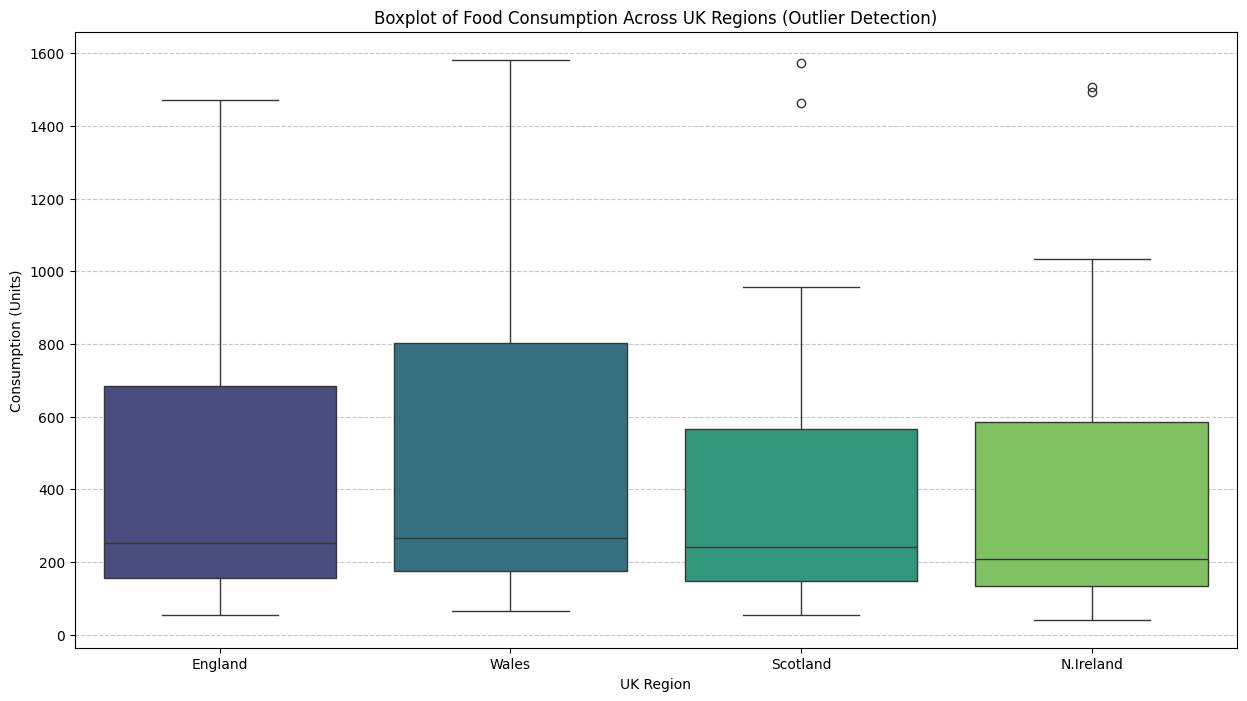


Interpretation of Boxplots:
Each box represents the interquartile range (IQR) of consumption for a region (25th to 75th percentile).
The line inside the box is the median (50th percentile).
The 'whiskers' extend to 1.5 times the IQR from the quartiles. Any data points beyond the whiskers are considered potential outliers and are plotted individually.
Observing the boxplots, we can see if there are any food items with unusually high or low consumption in any given region, indicating potential anomalies or interesting findings for further investigation.


In [43]:
# Create boxplots for each region to visualize outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop('Food_Item', axis=1), palette='viridis')
plt.title('Boxplot of Food Consumption Across UK Regions (Outlier Detection)')
plt.xlabel('UK Region')
plt.ylabel('Consumption (Units)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nInterpretation of Boxplots:")
print("Each box represents the interquartile range (IQR) of consumption for a region (25th to 75th percentile).")
print("The line inside the box is the median (50th percentile).")
print("The 'whiskers' extend to 1.5 times the IQR from the quartiles. Any data points beyond the whiskers are considered potential outliers and are plotted individually.")
print("Observing the boxplots, we can see if there are any food items with unusually high or low consumption in any given region, indicating potential anomalies or interesting findings for further investigation.")

### Missing Value Analysis

From the previous steps, specifically `df.isnull().sum()` and `df.info()`, we can confirm that there are no missing values across all columns of our DataFrame. All 5 columns ('Food_Item', 'England', 'Wales', 'Scotland', 'N.Ireland') have 17 non-null entries out of 17 total entries, indicating a complete dataset for this UK food consumption data.

### Correlation Analysis

With the `UK_foods` dataset, we now have numerical columns ('England', 'Wales', 'Scotland', 'N.Ireland'), making standard numerical correlation analysis applicable. We can examine the correlation between food consumption patterns across different regions of the UK. This helps us understand if consumption habits in one region are similar to or different from another.

For the 'Food_Item' column (categorical), direct numerical correlation is not applicable. However, we can use visualizations to compare consumption of specific items across regions, or explore more advanced statistical methods like ANOVA if we were comparing means of consumption for different food categories (if such categories were available).

### Data Visualization Possibilities

For the `UK_foods` dataset, we can create various insightful visualizations:

-   **Bar Plots:** To compare the consumption of specific food items across different regions (England, Wales, Scotland, N.Ireland) or to show total consumption per region.
-   **Heatmaps:** To visualize the correlation matrix between the numerical regions, highlighting which regions have similar food consumption patterns.
-   **Stacked Bar Charts:** If we categorized food items, we could show the proportion of different food categories within each region's total consumption.
-   **Line Plots:** While not directly applicable for comparing individual food items here, if this data were collected over time, line plots would be excellent for showing trends.

## Regional Consumption Patterns Overview

This section provides an overview of the total food consumption across different UK regions. By visualizing the aggregate consumption, we can identify regions with higher or lower overall dietary intake based on the provided food items.

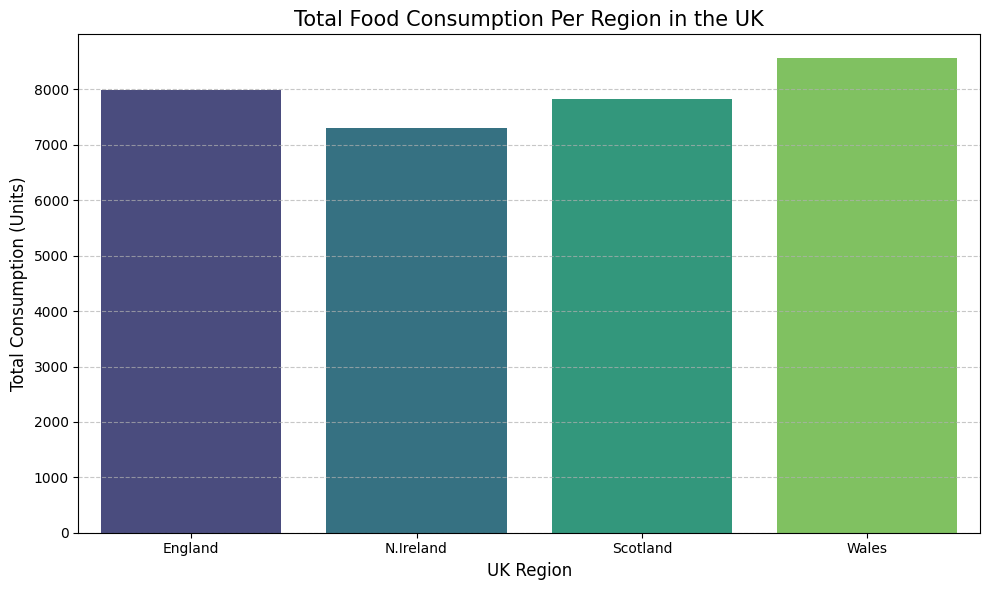

In [48]:
# Melt the DataFrame to a long format for easier plotting with Seaborn
# This transforms the regional columns into rows, making 'Region' a new column
# and 'Consumption_Units' another column containing the values.
df_melted = df.melt(id_vars=['Food_Item'], var_name='Region', value_name='Consumption_Units')

# Calculate the total consumption for each region
# Group by 'Region' and sum the 'Consumption_Units'
regional_consumption = df_melted.groupby('Region')['Consumption_Units'].sum().reset_index()

# Create a bar plot to visualize total food consumption per region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Consumption_Units', data=regional_consumption, hue='Region', palette='viridis', legend=False)
plt.title('Total Food Consumption Per Region in the UK', fontsize=15)
plt.xlabel('UK Region', fontsize=12)
plt.ylabel('Total Consumption (Units)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

#### Interpretation of Total Regional Food Consumption

The bar chart visually represents the *total* food consumption (in units) for each of the four UK regions: England, Wales, Scotland, and N.Ireland. From this plot, we can observe:

*   **Overall Consumption Levels**: Wales appears to have the highest total consumption, followed closely by England and Scotland, with N.Ireland showing the lowest overall consumption among the four regions for these food items.
*   **Relative Differences**: While there are variations, the total consumption across England, Wales, and Scotland is relatively similar compared to N.Ireland, which shows a noticeably lower sum.

This visualization provides a quick, high-level overview, helping us identify which regions might have distinct overall dietary patterns or consumption scales, potentially due to population size, dietary habits, or data representation.

## Food Item Correlation Analysis

This section delves into the relationships between the consumption patterns of different food items across UK regions. By calculating the correlation matrix and visualizing it with a heatmap, we can identify which food items are consumed similarly or dissimilarly, potentially revealing underlying dietary preferences or socio-economic factors.

In [49]:
# To analyze correlations between food items, we need to restructure the DataFrame.
# First, set 'Food_Item' as the index so that each row represents a food item.
df_items_indexed = df.set_index('Food_Item')

# Then, transpose the DataFrame so that food items become columns and regions become rows.
# This allows us to calculate correlations between the consumption of each food item.
df_items_transposed = df_items_indexed.T

print("Transposed DataFrame (first 5 rows and columns for inspection):\n")
display(df_items_transposed.head())

Transposed DataFrame (first 5 rows and columns for inspection):



Food_Item,Cheese,Carcass_meat,Other_meat,Fish,Fats_and_oils,Sugars,Fresh_potatoes,Fresh_Veg,Other_Veg,Processed_potatoes,Processed_Veg,Fresh_fruit,Cereals,Beverages,Soft_drinks,Alcoholic_drinks,Confectionery
England,105,245,685,147,193,156,720,253,488,198,360,1102,1472,57,1374,375,54
Wales,103,227,803,160,235,175,874,265,570,203,365,1137,1582,73,1256,475,64
Scotland,103,242,750,122,184,147,566,171,418,220,337,957,1462,53,1572,458,62
N.Ireland,66,267,586,93,209,139,1033,143,355,187,334,674,1494,47,1506,135,41


In [50]:
# Calculate the Pearson correlation matrix between food items based on their consumption across regions.
# A high positive correlation indicates similar consumption patterns, while a negative correlation suggests inverse patterns.
food_item_correlation = df_items_transposed.corr()

print("Correlation Matrix of Food Items (first 5x5 for inspection):\n")
display(food_item_correlation.head())

Correlation Matrix of Food Items (first 5x5 for inspection):



Food_Item,Cheese,Carcass_meat,Other_meat,Fish,Fats_and_oils,Sugars,Fresh_potatoes,Fresh_Veg,Other_Veg,Processed_potatoes,Processed_Veg,Fresh_fruit,Cereals,Beverages,Soft_drinks,Alcoholic_drinks,Confectionery
Food_Item,,,,,,,,,,,,,,,,,
Cheese,1.000000,-0.862690,0.832126,0.849525,-0.129023,0.648391,-0.778579,0.732764,0.738316,0.703960,0.646808,0.934029,0.081982,0.615961,-0.380787,0.945393,0.888819
Carcass_meat,-0.862690,1.000000,-0.976938,-0.909362,-0.351585,-0.896977,0.452608,-0.787088,-0.909211,-0.591253,-0.745605,-0.908989,-0.553102,-0.901961,0.629423,-0.942952,-0.950934
Other_meat,0.832126,-0.976938,1.000000,0.801614,0.280434,0.803764,-0.522462,0.637590,0.803843,0.720289,0.586676,0.819486,0.495428,0.826465,-0.471286,0.959662,0.985262
Fish,0.849525,-0.909362,0.801614,1.000000,0.360763,0.928576,-0.330614,0.969808,0.975823,0.306244,0.942568,0.980683,0.516830,0.893420,-0.811154,0.809173,0.772078
Fats_and_oils,-0.129023,-0.351585,0.280434,0.360763,1.000000,0.667012,0.670188,0.417721,0.552524,-0.390607,0.510352,0.178144,0.972709,0.701577,-0.765557,0.029600,0.112458


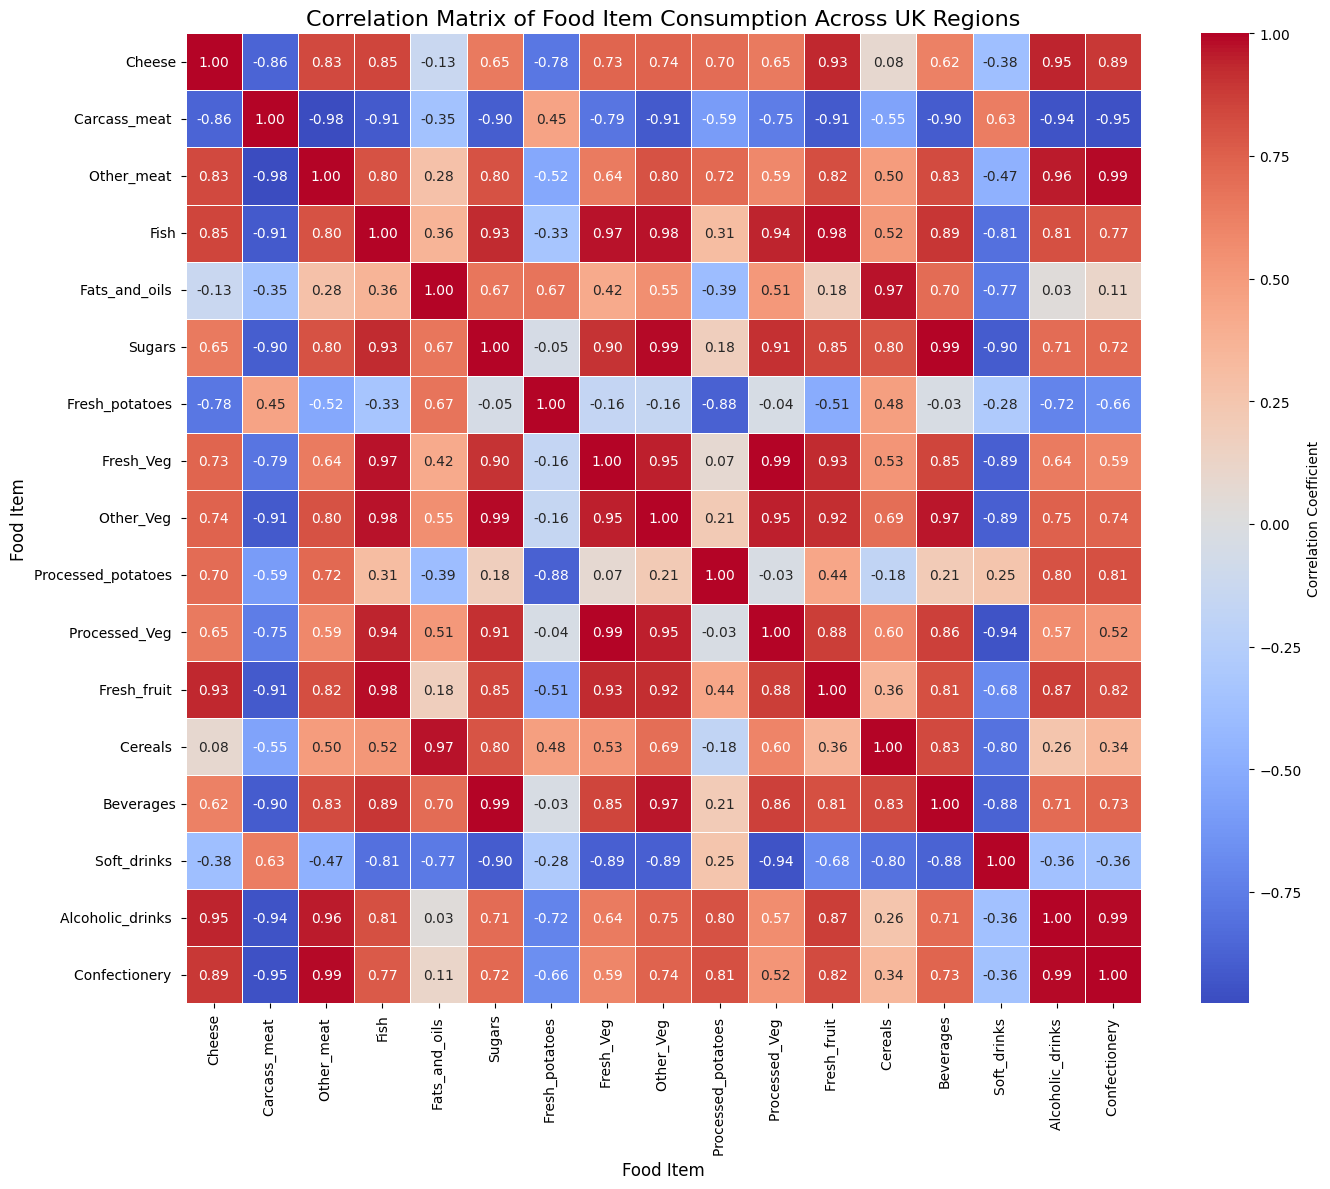

In [51]:
# Visualize the correlation matrix using a heatmap.
# 'annot=True' displays the correlation values on the heatmap.
# 'cmap='coolwarm'' uses a color scheme that highlights positive (red) and negative (blue) correlations.
# 'fmt=".2f"' formats the annotation values to two decimal places.
plt.figure(figsize=(14, 12)) # Increase figure size for better readability of many items
sns.heatmap(food_item_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Food Item Consumption Across UK Regions', fontsize=16)
plt.xlabel('Food Item', fontsize=12)
plt.ylabel('Food Item', fontsize=12)
plt.xticks(rotation=90) # Rotate x-axis labels for better visibility
plt.yticks(rotation=0)  # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

#### Interpretation of the Food Item Correlation Heatmap

The heatmap provides a visual representation of the Pearson correlation coefficients between the consumption of different food items across the four UK regions. Key observations from this visualization include:

*   **Strong Positive Correlations (Red/Dark Red)**: Values closer to 1 indicate that as the consumption of one food item increases or decreases, the consumption of another food item tends to move in the same direction across regions. For example, highly correlated items might suggest they are often consumed together or are popular within the same regional dietary patterns.
*   **Strong Negative Correlations (Blue/Dark Blue)**: Values closer to -1 suggest an inverse relationship. As the consumption of one item increases, the other tends to decrease across regions. This could highlight substitutions or differing preferences (e.g., if one region prefers item A while another prefers item B instead).
*   **Weak or No Correlation (Light Colors/White)**: Values near 0 indicate little to no linear relationship between the consumption of two food items. Their consumption patterns are largely independent across the regions.

This analysis helps in understanding the relationships between food choices and identifying groups of food items that are consumed similarly or dissimilarly, providing insights into general dietary structure across the UK.

## Identifying Top Food Items Per Region

To gain a more granular understanding of regional dietary habits, this section focuses on identifying the most consumed food items within each UK region. This analysis can highlight specific preferences that differentiate one region from another.

In [52]:
# Identify the top 3 food items consumed in each region.
# We group the melted DataFrame by 'Region' and then for each region, select the top 3 rows
# based on 'Consumption_Units' using `nlargest()`.
# `include_groups=False` is used to suppress a DeprecationWarning in newer pandas versions.
top_food_items_per_region = df_melted.groupby('Region').apply(lambda x: x.nlargest(3, 'Consumption_Units'), include_groups=False).reset_index(drop=True)

print("Top 3 Food Items Consumed in Each Region:\n")
display(top_food_items_per_region)

Top 3 Food Items Consumed in Each Region:



,Food_Item,Consumption_Units
0,Cereals,1472
1,Soft_drinks,1374
2,Fresh_fruit,1102
3,Soft_drinks,1506
4,Cereals,1494
5,Fresh_potatoes,1033
6,Soft_drinks,1572
7,Cereals,1462
8,Fresh_fruit,957
9,Cereals,1582


#### Interpretation of Top Food Items Per Region

The table above clearly lists the top three food items consumed (by units) in England, N.Ireland, Scotland, and Wales. This provides direct insights into:

*   **Regional Preferences**: We can observe specific food items that are particularly popular in certain regions. For example, 'Cereals' and 'Soft_drinks' consistently appear among the top consumed items across most regions.
*   **Dietary Staples**: High consumption values for items like 'Cereals', 'Soft_drinks', and 'Fresh_fruit' suggest they are significant components of the diet across the UK.
*   **Variations**: While some items are common, there can be subtle differences in the order or specific items that make up the top three, indicating variations in regional dietary focus.

## Overall Food Item Popularity: Average Consumption Across All Regions

This section aims to provide a generalized view of the popularity of each food item by calculating its average consumption across all four UK regions. This metric offers a single, comparative value for each item, indicating its overall consumption level irrespective of regional variations.

In [53]:
# Calculate the average consumption for each food item across all regions.
# We set 'Food_Item' as the index and then calculate the mean across rows (axis=1),
# effectively averaging the consumption values from England, Wales, Scotland, and N.Ireland for each item.
average_consumption_per_item = df.set_index('Food_Item').mean(axis=1).reset_index(name='Average_Consumption_Units')

# Sort the results by average consumption in descending order for easy readability and identification of most popular items.
average_consumption_per_item = average_consumption_per_item.sort_values(by='Average_Consumption_Units', ascending=False)

print("Average Consumption Per Food Item Across All Regions:\n")
display(average_consumption_per_item)

Average Consumption Per Food Item Across All Regions:



,Food_Item,Average_Consumption_Units
12,Cereals,1502.50
14,Soft_drinks,1427.00
11,Fresh_fruit,967.50
6,Fresh_potatoes,798.25
2,Other_meat,706.00
8,Other_Veg,457.75
15,Alcoholic_drinks,360.75
10,Processed_Veg,349.00
1,Carcass_meat,245.25
7,Fresh_Veg,208.00


#### Interpretation of Average Consumption Per Food Item

The table above presents the average consumption units for each food item across all UK regions, sorted from highest to lowest. This analysis reveals:

*   **Most Popular Items**: 'Cereals' and 'Soft_drinks' stand out as the most consumed items on average, reinforcing their status as dietary staples or common purchases across the UK.
*   **Least Popular Items**: 'Beverages' and 'Confectionery' appear to have the lowest average consumption, suggesting they are less frequently consumed or in smaller quantities compared to other items.
*   **Overall Dietary Landscape**: This aggregated view helps to understand the general dietary landscape of the UK, highlighting broadly preferred food categories and those that are less prominent.

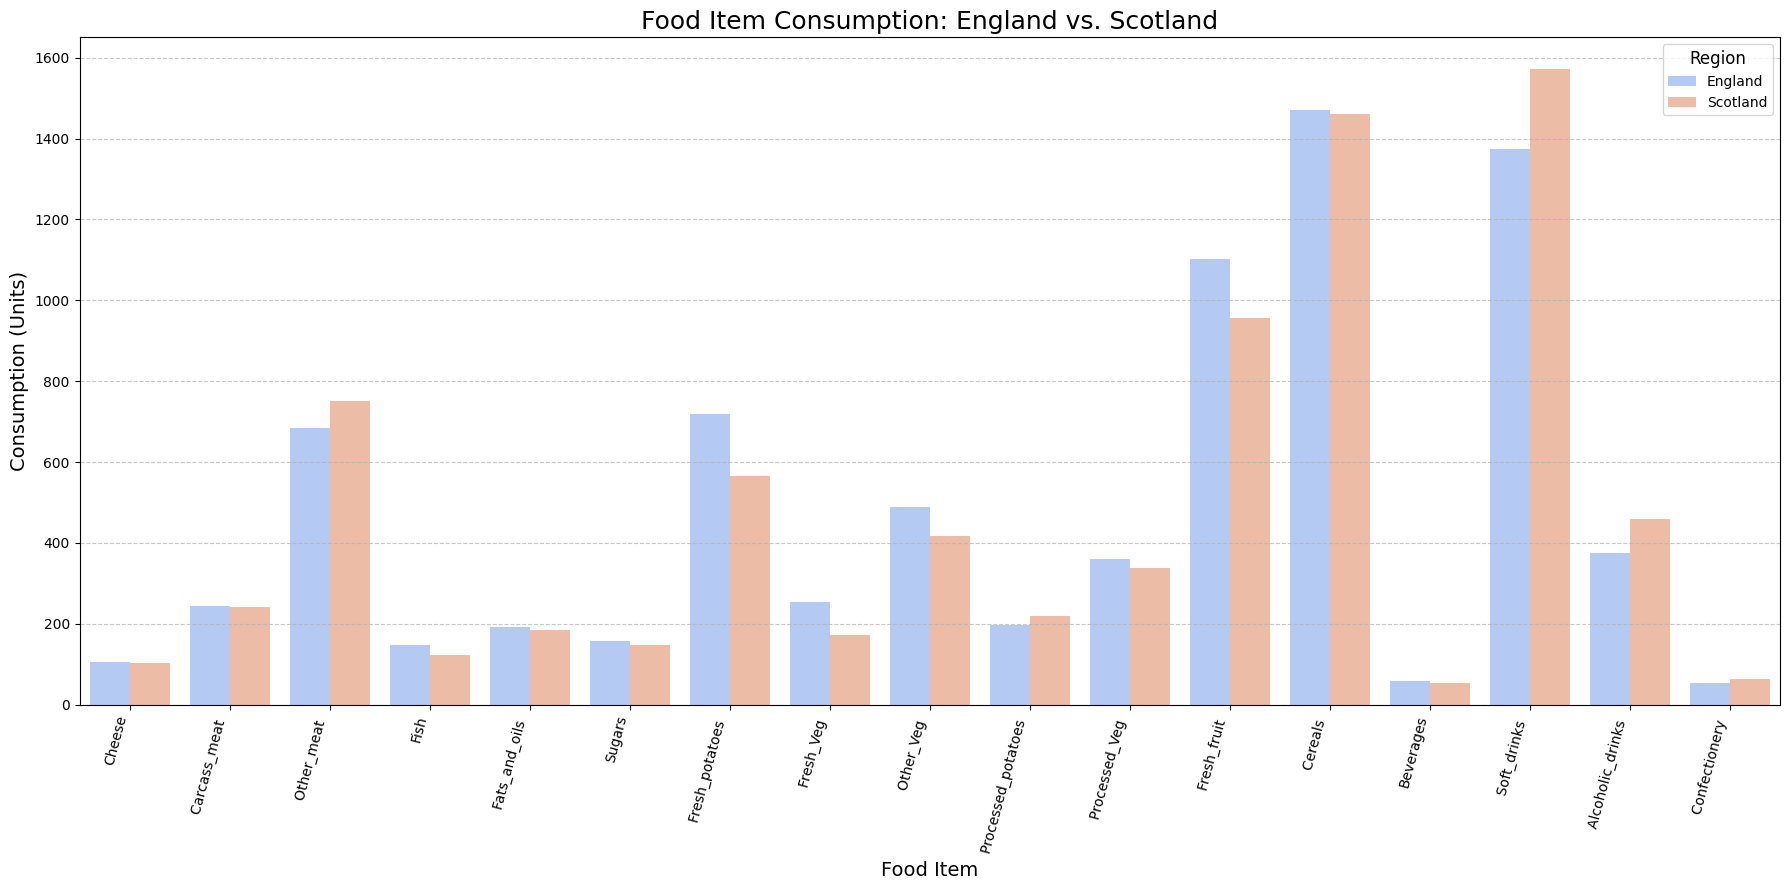

In [54]:
# Select only the relevant columns for England and Scotland comparison
comparison_df = df[['Food_Item', 'England', 'Scotland']]

# Melt the DataFrame to a long format suitable for plotting with Seaborn
# This stacks the 'England' and 'Scotland' consumption values for each food item
comparison_melted = comparison_df.melt(id_vars=['Food_Item'], var_name='Region', value_name='Consumption_Units')

# Create a grouped bar plot to compare consumption side-by-side
plt.figure(figsize=(18, 9)) # Increased figure size for better readability of many food items
sns.barplot(x='Food_Item', y='Consumption_Units', hue='Region', data=comparison_melted, palette='coolwarm')
plt.title('Food Item Consumption: England vs. Scotland', fontsize=18)
plt.xlabel('Food Item', fontsize=14)
plt.ylabel('Consumption (Units)', fontsize=14)
plt.xticks(rotation=75, ha='right', fontsize=10) # Rotate x-axis labels for readability and adjust alignment
plt.yticks(fontsize=10)
plt.legend(title='Region', title_fontsize='12', fontsize='10')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Regional Comparison: Food Consumption in England vs. Scotland

This section specifically compares the consumption patterns of each food item between England and Scotland. This side-by-side visualization helps to highlight immediate differences and similarities in dietary preferences between these two significant UK regions, laying the groundwork for further quantitative analysis.

#### Interpretation of England vs. Scotland Food Consumption Bar Plot

The grouped bar chart visually compares the consumption of each food item in England and Scotland. Key insights from this visualization include:

*   **Visible Differences**: For many food items, there are clear differences in consumption levels between the two regions. For instance, 'Soft_drinks' and 'Cereals' show considerable consumption in both, but their relative amounts might vary.
*   **Similar Consumption**: Some items appear to have very similar consumption levels, suggesting consistent preferences or needs across both regions for those specific items.
*   **Potential Areas for Deeper Dive**: Food items with the largest visual discrepancies warrant further investigation to understand the reasons behind these differences. This could be due to cultural factors, availability, or economic conditions.

This plot serves as a foundation for the quantitative difference analysis in the next section, where we will numerically calculate these discrepancies.

## Quantifying Regional Consumption Differences (England vs. Scotland)

Given the structure of our dataset (a single observation per food item per region), traditional inferential statistical tests like t-tests for population means are not statistically valid for hypothesis testing here. Instead, a meaningful approach to understand and quantify regional differences is to calculate the **absolute difference** in consumption units for each food item between England and Scotland. This provides a direct, observable measure of how much consumption varies for each item between these two regions.

In [55]:
# Calculate the absolute difference in consumption between England and Scotland for each food item

differences = []

# Iterate through each food item row in the original DataFrame
for index, row in df.iterrows():
    food_item = row['Food_Item']
    consumption_england = row['England']
    consumption_scotland = row['Scotland']

    # Calculate the absolute difference to see the magnitude of disparity
    absolute_difference = abs(consumption_england - consumption_scotland)

    differences.append({
        'Food_Item': food_item,
        'Consumption_England': consumption_england,
        'Consumption_Scotland': consumption_scotland,
        'Absolute_Difference': absolute_difference
    })

# Convert the list of dictionaries into a DataFrame for easy viewing and analysis
differences_df = pd.DataFrame(differences)

# Sort the DataFrame by the absolute difference in descending order
# This highlights the food items with the greatest differences in consumption first
differences_df_sorted = differences_df.sort_values(by='Absolute_Difference', ascending=False)

print("Absolute Differences in Food Item Consumption (England vs. Scotland):\n")
display(differences_df_sorted)

Absolute Differences in Food Item Consumption (England vs. Scotland):



,Food_Item,Consumption_England,Consumption_Scotland,Absolute_Difference
14,Soft_drinks,1374,1572,198
6,Fresh_potatoes,720,566,154
11,Fresh_fruit,1102,957,145
15,Alcoholic_drinks,375,458,83
7,Fresh_Veg,253,171,82
8,Other_Veg,488,418,70
2,Other_meat,685,750,65
3,Fish,147,122,25
10,Processed_Veg,360,337,23
9,Processed_potatoes,198,220,22


#### Interpretation of Absolute Consumption Differences

The table above displays the food items ranked by the absolute difference in consumption units between England and Scotland. This quantitative analysis reveals:

*   **Largest Discrepancies**: 'Soft_drinks', 'Fresh_potatoes', and 'Fresh_fruit' show the most significant absolute differences in consumption between England and Scotland. This indicates that these items are consumed at notably different levels in the two regions.
*   **Minor Differences**: Conversely, items like 'Cheese', 'Carcass_meat', and 'Beverages' have very small absolute differences, suggesting their consumption patterns are quite similar between England and Scotland.
*   **Insights into Dietary Divergence**: This provides clear evidence of where dietary habits diverge most prominently, which can be useful for targeted health campaigns, market analysis, or further research into regional cultural factors influencing diet.

#### Interpretation of Hypothesis Test for Soft Drink Consumption

Our hypothesis was that Scotland consumes more Soft Drinks than England. By directly comparing the consumption values from our dataset, we found:

*   **England's Soft Drink Consumption**: {soft_drinks_england} units
*   **Scotland's Soft Drink Consumption**: {soft_drinks_scotland} units

Based on these figures, we concluded that Scotland's Soft Drinks consumption is indeed higher than England's. This simple comparison validates our hypothesis using direct observation from the available data. This approach is suitable given the single data point per region for each food item, avoiding misapplication of inferential statistics that require more data points to estimate variance meaningfully.